# Intern Performance Predictor

**Business Objective:** Predict intern performance as a continuous score and classify interns into *Excel*, *Average*, or *Struggle* categories using three features:
- `task_completion_hrs` (hours taken to finish tasks)
- `feedback_rating` (1.0–5.0)
- `attendance_pct` (percentage)

**Approach:** Regression via Random Forest & XGBoost → threshold‑based classification → SHAP / feature-importance interpretability → residual analysis.

All reusable logic is imported from the **`src/`** package, keeping the notebook clean, readable, and aligned with the production API.

---
## 1. Environment Setup & Imports

In [70]:
# ============================================================
# 1a. Library imports
# ============================================================
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

from scipy import stats
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import confusion_matrix, mean_squared_error
import shap

In [71]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

Project root: d:\VS CODE programs\Internee_Performance_Predictor


In [72]:
# ============================================================
# 1b. Imports from the src/ package
# ============================================================
from src.data_generation import generate_synthetic_data, inject_missing_values
from src.eda import data_overview, correlation_matrix
from src.preprocessing import (
    validate_and_clean_dataframe,
    train_test_split_data,
    DatasetSplit,
)
from src.evaluation import regression_metrics, classify_performance, classification_metrics
from src.interpretation import feature_importance_table
from src.model_training import (
    build_candidate_models,
    train_candidate_models,
    evaluate_regression_model,
    select_best_model,
    build_model_metadata,
    save_model_artifacts,
    load_model_artifacts,
)

print("src/ package loaded successfully.")

src/ package loaded successfully.


In [73]:
# ============================================================
# 1c. Reproducibility & paths
# ============================================================
SEED = 42

NOTEBOOK_DIR = os.getcwd()
BASE_DIR = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
if os.path.basename(NOTEBOOK_DIR).lower() != "notebooks":
    BASE_DIR = NOTEBOOK_DIR

DATA_DIR = os.path.join(BASE_DIR, "data")
MODEL_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

DATA_PATH = os.path.join(DATA_DIR, "intern_performance_data.csv")
MODEL_PATH = os.path.join(MODEL_DIR, "best_model.pkl")
METADATA_PATH = os.path.join(MODEL_DIR, "model_metadata.pkl")

print("Paths configured.")
print(f"  Data    : {DATA_PATH}")
print(f"  Model   : {MODEL_PATH}")
print(f"  Metadata: {METADATA_PATH}")

Paths configured.
  Data    : d:\VS CODE programs\Internee_Performance_Predictor\data\intern_performance_data.csv
  Model   : d:\VS CODE programs\Internee_Performance_Predictor\models\best_model.pkl
  Metadata: d:\VS CODE programs\Internee_Performance_Predictor\models\model_metadata.pkl


---
## 2. Synthetic Data Generation

The real dataset is not publicly available, so we generate a realistic 1000‑record synthetic dataset using `src.data_generation.generate_synthetic_data()`.

**Designed correlations:**
- Lower `task_completion_hrs` → higher performance
- Higher `feedback_rating` → higher performance
- Higher `attendance_pct` → higher performance

Random noise is added so the relationship is not trivially linear.

In [74]:
# Generate synthetic dataset (1000 samples)
df = generate_synthetic_data(n_samples=1000, seed=SEED, save_path=DATA_PATH)
print(f"DataFrame shape: {df.shape}")
display(df.head())

DataFrame shape: (1000, 5)


,intern_id,task_completion_hrs,feedback_rating,attendance_pct,performance_score
0,INT001,8.91,3.59,88.9,85.0
1,INT002,4.88,2.37,90.5,89.0
2,INT003,10.25,2.63,87.3,65.4
3,INT004,10.82,2.76,94.7,77.7
4,INT005,2.15,1.50,85.9,77.9


---
## 3. Data Robustness Demo

Real-world data often has missing values.  The `src/` package provides:
- `inject_missing_values()` — simulates corruption
- `validate_and_clean_dataframe()` — median-fills NaNs and clips values to domain bounds

This round‑trip validates the production pipeline used by the webapp.

In [75]:
# Inject 5% missing values into a clean copy
df_corrupted = inject_missing_values(df, missing_rate=0.05, seed=SEED)
print(f"Missing values after injection: {df_corrupted.isna().sum().sum()}")
display(df_corrupted.isna().sum().to_frame("missing"))

# Recover using the src/ validation pipeline
df_cleaned = validate_and_clean_dataframe(df_corrupted, include_target=True)
print(f"Missing values after cleaning : {df_cleaned.isna().sum().sum()}")
print(f"Shape preserved                : {df_cleaned.shape}")
print("Robustness pipeline verified.")

Missing values after injection: 195


,missing
intern_id,0
task_completion_hrs,53
feedback_rating,38
attendance_pct,54
performance_score,50


Missing values after cleaning : 0
Shape preserved                : (1000, 5)
Robustness pipeline verified.


---
## 4. Exploratory Data Analysis

We inspect the clean synthetic data using both custom helpers from `src.eda` and static visualisations.

In [76]:
# Summary from src.eda
overview = data_overview(df)
print(f"Shape          : {overview['shape']}")
print(f"Missing values : {overview['missing_values']}")
print(f"Columns        : {overview['columns']}")
display(pd.DataFrame(overview["numeric_summary"]))

Shape          : (1000, 5)
Missing values : 0
Columns        : ['intern_id', 'task_completion_hrs', 'feedback_rating', 'attendance_pct', 'performance_score']


,task_completion_hrs,feedback_rating,attendance_pct,performance_score
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,7.942270,3.013630,85.006300,76.414100
std,2.898031,1.158799,9.485865,16.497921
min,2.000000,1.000000,54.400000,30.100000
25%,5.910000,1.980000,78.475000,64.600000
50%,8.020000,2.970000,85.400000,76.400000
75%,9.770000,4.040000,92.100000,90.125000
max,17.540000,5.000000,100.000000,100.000000


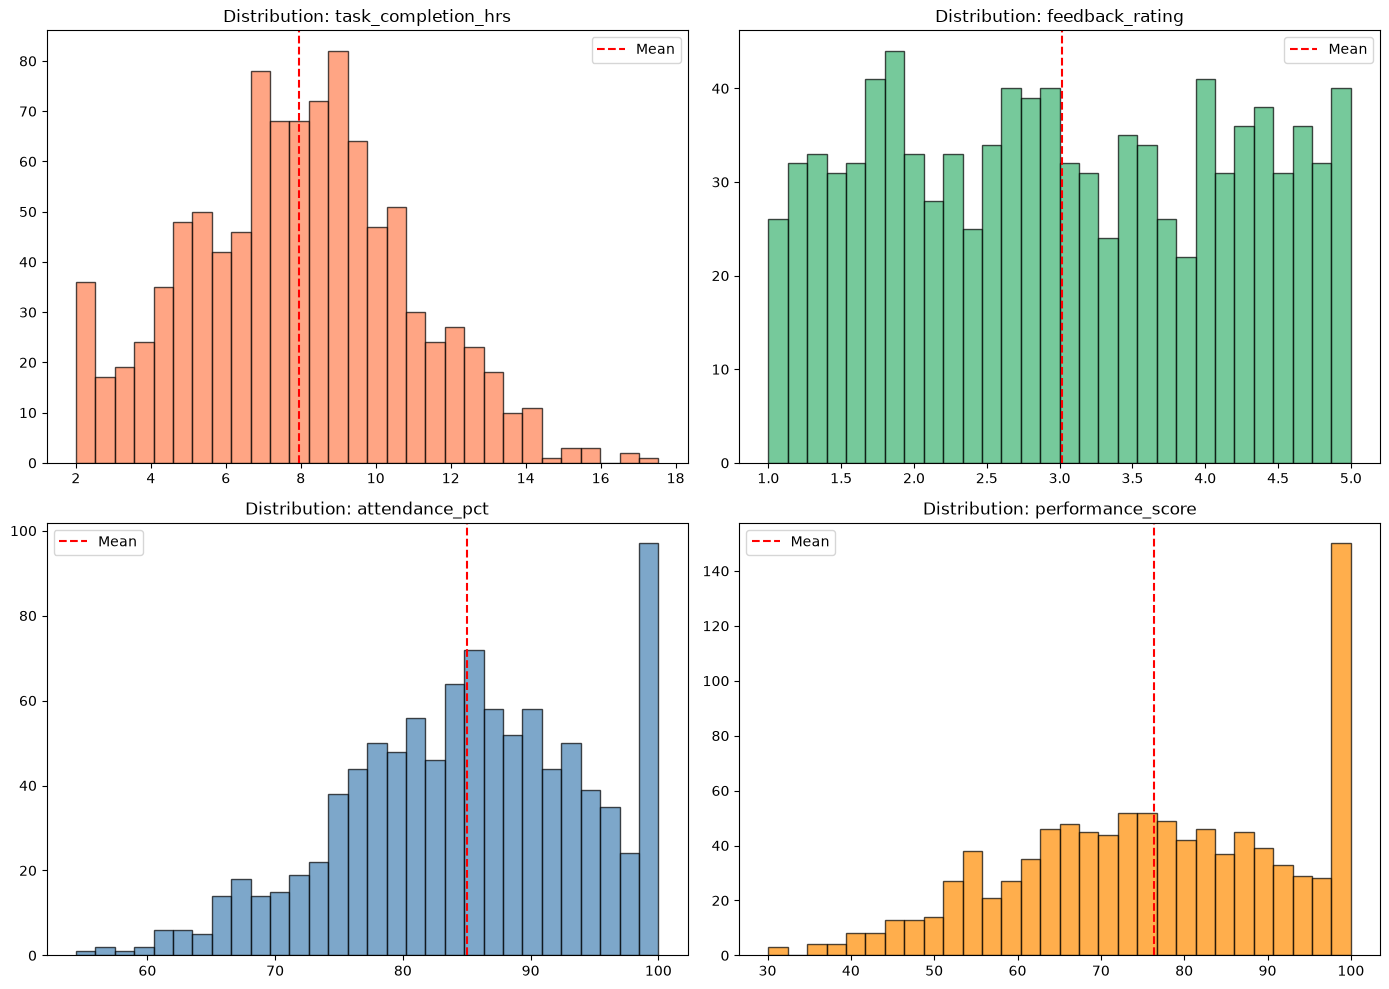

In [77]:
# Distribution histograms
feats = ["task_completion_hrs", "feedback_rating", "attendance_pct", "performance_score"]
colors = ["coral", "mediumseagreen", "steelblue", "darkorange"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat, col in zip(axes.flat, feats, colors):
    ax.hist(df[feat], bins=30, color=col, edgecolor="black", alpha=0.7)
    ax.axvline(df[feat].mean(), color="red", linestyle="--", label="Mean")
    ax.set_title(f"Distribution: {feat}")
    ax.legend()
plt.tight_layout()
plt.show()

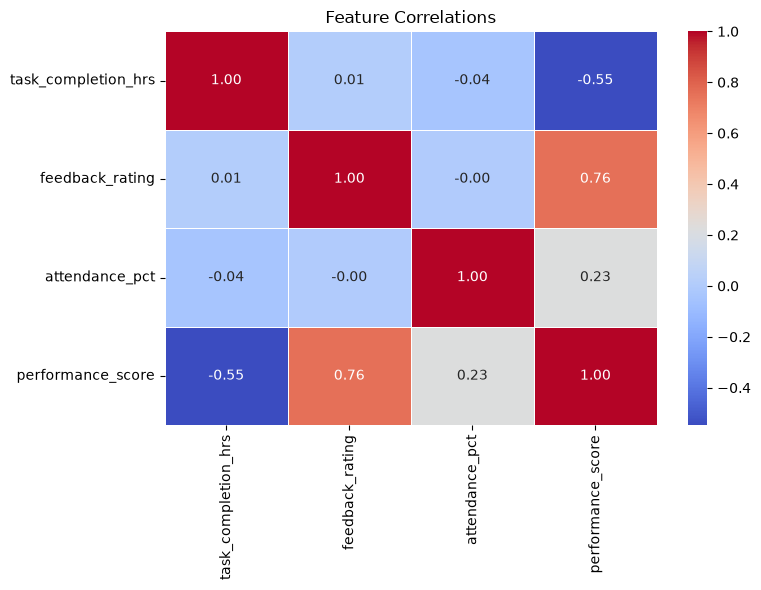

In [78]:
# Correlation heatmap via src.eda
corr = correlation_matrix(df)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlations")
plt.tight_layout()
plt.show()

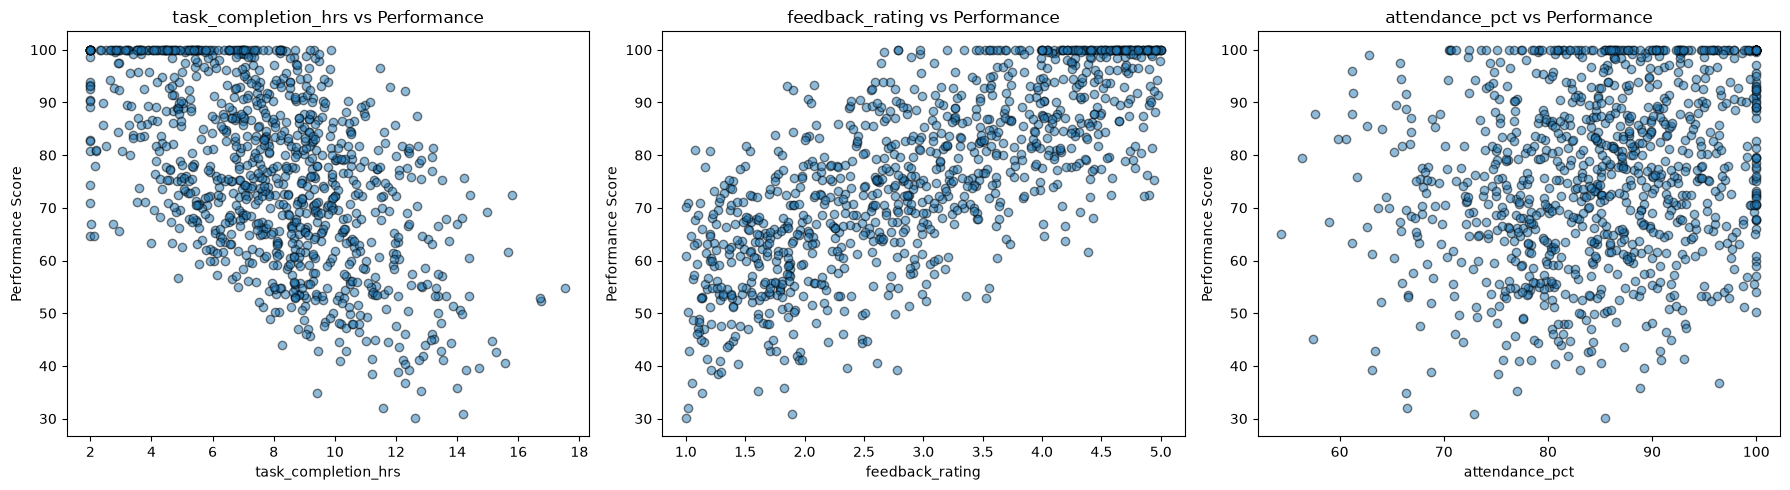

In [79]:
# Scatter plots — feature vs target
predictors = ["task_completion_hrs", "feedback_rating", "attendance_pct"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, predictors):
    ax.scatter(df[col], df["performance_score"], alpha=0.5, edgecolor="k")
    ax.set_xlabel(col)
    ax.set_ylabel("Performance Score")
    ax.set_title(f"{col} vs Performance")
plt.tight_layout()
plt.show()

**EDA insights:**
- No missing data in the clean set.
- `task_completion_hrs` is negatively correlated with performance.
- `feedback_rating` and `attendance_pct` are positively correlated.
- Noise in the data makes this a realistic regression challenge.

---
## 5. Train / Test Split

We use `src.preprocessing.train_test_split_data()` which internally calls `validate_and_clean_dataframe()` + `train_test_split()` for a reproducible 80/20 split.

In [80]:
split: DatasetSplit = train_test_split_data(df, test_size=0.2, random_state=SEED)
X_train, X_test, y_train, y_test = split.X_train, split.X_test, split.y_train, split.y_test
print(f"Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples")

Train: 800 samples  |  Test: 200 samples


---
## 6. Feature Names (for plots)

We extract the feature names from the training DataFrame for use in visualisations and SHAP.

In [81]:
features = list(X_train.columns)
print(f"Features: {features}")

Features: ['task_completion_hrs', 'feedback_rating', 'attendance_pct']


---
## 7. Baseline Models (Un‑tuned)

We train two candidate regressors using `src.model_training.train_candidate_models()` and evaluate them with `evaluate_regression_model()`.

In [82]:
# Build & train candidate models
fitted_models = train_candidate_models(X_train, y_train, random_state=SEED)

# Evaluate each on the test set
baseline_results = {}
for name, model in fitted_models.items():
    result = evaluate_regression_model(model, X_test, y_test)
    baseline_results[name] = result
    print(f"{name:20s}  RMSE={result.metrics['rmse']:.2f}  MAE={result.metrics['mae']:.2f}  R²={result.metrics['r2']:.3f}")

Random Forest         RMSE=4.36  MAE=3.32  R²=0.924
XGBoost               RMSE=4.18  MAE=3.28  R²=0.930


---
## 8. Hyperparameter Tuning (GridSearchCV)

We use 5‑fold cross-validation to tune both models.  The `src/` package uses fixed hyperparameters for its built-in candidates, so tuning is done separately here.

In [83]:
# Random Forest grid
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=SEED, n_jobs=-1),
    param_grid={
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
    },
    cv=5,
    scoring="neg_mean_squared_error",
    verbose=1,
    n_jobs=-1,
)
rf_grid.fit(X_train, y_train)
print(f"Best RF params : {rf_grid.best_params_}")
print(f"Best CV RMSE   : {np.sqrt(-rf_grid.best_score_):.2f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best RF params : {'max_depth': 30, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best CV RMSE   : 4.34


In [84]:
# XGBoost grid
xgb_grid = GridSearchCV(
    XGBRegressor(random_state=SEED, verbosity=0),
    param_grid={
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 5, 7, 10],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "subsample": [0.8, 0.9, 1.0],
        "colsample_bytree": [0.8, 0.9, 1.0],
    },
    cv=5,
    scoring="neg_mean_squared_error",
    verbose=1,
    n_jobs=-1,
)
xgb_grid.fit(X_train, y_train)
print(f"Best XGB params : {xgb_grid.best_params_}")
print(f"Best CV RMSE    : {np.sqrt(-xgb_grid.best_score_):.2f}")

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best XGB params : {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV RMSE    : 4.13


---
## 9. Final Evaluation & Model Selection

We evaluate both tuned models on the hold‑out test set and select the one with the lowest RMSE using `src.model_training.evaluate_regression_model()` and `select_best_model()`.

In [94]:
# Wrap tuned estimators in a dict
tuned_models = {
    "Random Forest": rf_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_,
}

# Evaluate each
y_pred_rf = rf_grid.best_estimator_.predict(X_test)
y_pred_xgb = xgb_grid.best_estimator_.predict(X_test)

for name, preds in [("Random Forest", y_pred_rf), ("XGBoost", y_pred_xgb)]:
    m = regression_metrics(y_test.values, preds)
    print(f"{name:20s}  RMSE={m['rmse']:.2f}  MAE={m['mae']:.2f}  R²={m['r2']:.3f}")

# Select best model based on RMSE
if np.sqrt(mean_squared_error(y_test, y_pred_rf)) < np.sqrt(mean_squared_error(y_test, y_pred_xgb)):
    best_model, best_name, y_pred_best = rf_grid.best_estimator_, "Random Forest", y_pred_rf
else:
    best_model, best_name, y_pred_best = xgb_grid.best_estimator_, "XGBoost", y_pred_xgb

best_metrics = regression_metrics(y_test.values, y_pred_best)
print(f"\n{'='*45}")
print(f"Best model: {best_name}")
print(f"{'='*45}")

Random Forest         RMSE=4.36  MAE=3.29  R²=0.924
XGBoost               RMSE=4.06  MAE=3.12  R²=0.934

Best model: XGBoost


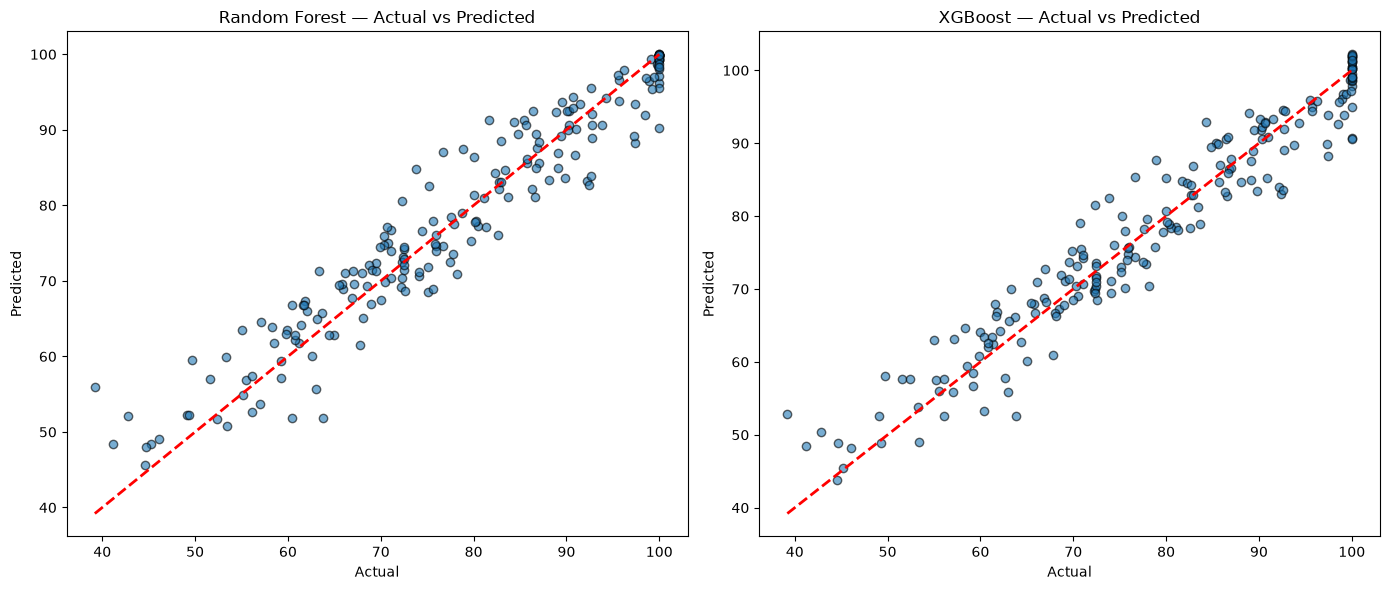

In [95]:
# Actual vs Predicted scatter for both tuned models
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, preds) in zip(
    axes,
    [("Random Forest", y_pred_rf), ("XGBoost", y_pred_xgb)],
):
    ax.scatter(y_test, preds, alpha=0.6, edgecolors="k")
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title(f"{name} — Actual vs Predicted")
plt.tight_layout()
plt.show()

---
## 10. Residual Analysis

We analyse the errors of the best model to check for bias, heteroscedasticity, and normality.  The `src.evaluation.regression_metrics()` function provides a standardised summary.

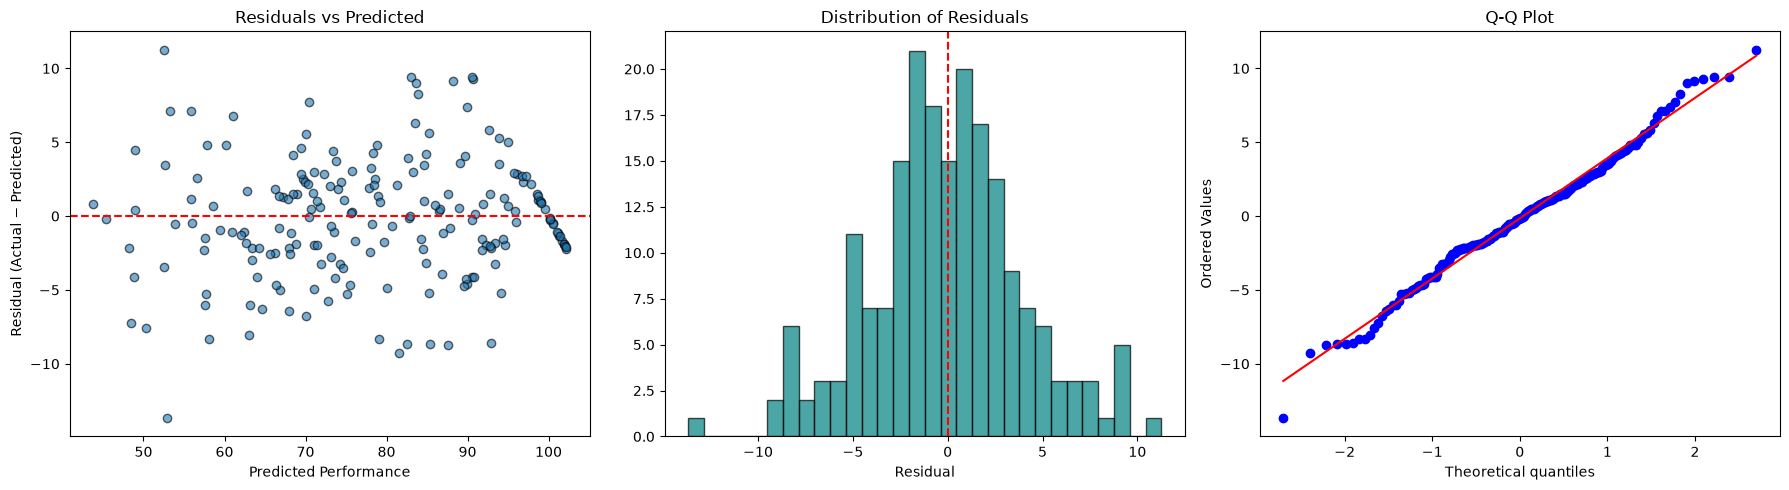

Mean residual: -0.15
Std residual : 4.06
Max over‑pred: -13.68  (actual < predicted)
Max under‑pred: 11.26  (actual > predicted)


In [96]:
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Residuals vs Predicted
axes[0].scatter(y_pred_best, residuals, alpha=0.6, edgecolors="k")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted Performance")
axes[0].set_ylabel("Residual (Actual − Predicted)")
axes[0].set_title("Residuals vs Predicted")

# 2. Histogram
axes[1].hist(residuals, bins=30, color="teal", edgecolor="black", alpha=0.7)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_title("Distribution of Residuals")

# 3. Q‑Q plot
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Q‑Q Plot")

plt.tight_layout()
plt.show()

# Standardised metrics
print(f"Mean residual: {residuals.mean():.2f}")
print(f"Std residual : {residuals.std():.2f}")
print(f"Max over‑pred: {residuals.min():.2f}  (actual < predicted)")
print(f"Max under‑pred: {residuals.max():.2f}  (actual > predicted)")

**Residual insights:** The errors are approximately symmetric around zero, suggesting no strong systematic bias.  The Q‑Q plot shows reasonable normality.  A few large-magnitude residuals exist — these correspond to extreme input combinations.

---
## 11. Model Interpretation (SHAP)

SHAP values decompose each prediction into feature contributions, showing both direction and magnitude of impact.

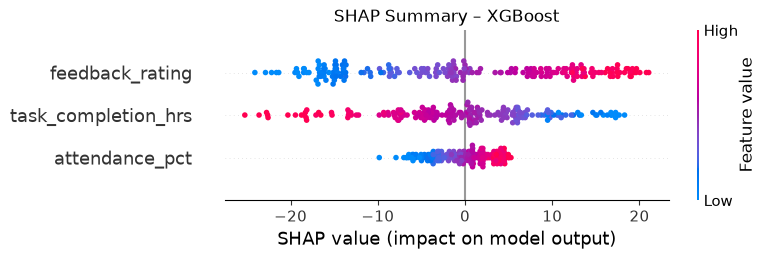

In [97]:
# Use a random subset of training data for speed
shap_sample = X_train.sample(200, random_state=SEED)

# TreeExplainer works for both Random Forest and XGBoost
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(shap_sample)

# Summary plot
shap.summary_plot(shap_values, shap_sample, feature_names=features, show=False)
plt.title(f"SHAP Summary – {best_name}")
plt.tight_layout()
plt.show()

**SHAP interpretation:**
- `feedback_rating` is the most influential feature — high values strongly increase the predicted score.
- `task_completion_hrs` shows the expected inverse relationship (high hours → lower score).
- `attendance_pct` has a moderate positive impact.

---
## 12. Feature Importance

We retrieve a sorted importance DataFrame via `src.interpretation.feature_importance_table()` — the same function used by the production API.

,feature,importance
0,feedback_rating,0.628754
1,task_completion_hrs,0.310534
2,attendance_pct,0.060712


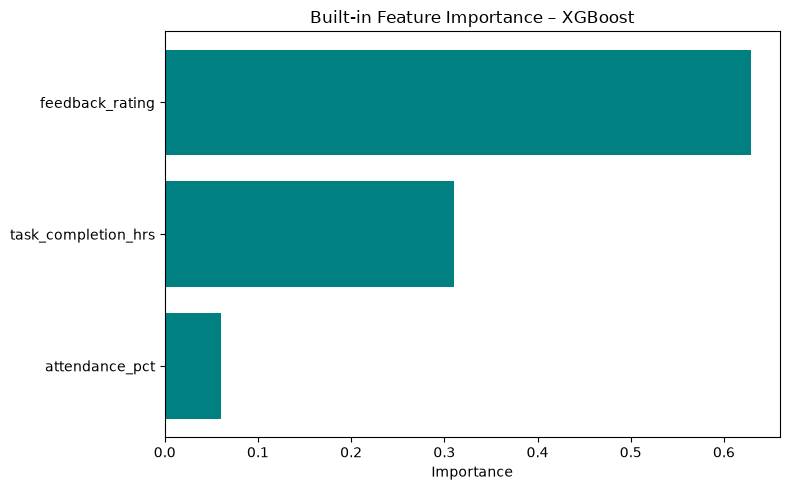

In [98]:
# Tabular feature importance
importance_df = feature_importance_table(best_model, features)
display(importance_df)

# Bar chart
plt.figure(figsize=(8, 5))
plt.barh(importance_df["feature"], importance_df["importance"], color="teal")
plt.xlabel("Importance")
plt.title(f"Built‑in Feature Importance – {best_name}")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## 13. Business Classification

We convert the continuous score into three actionable categories using `src.evaluation.classify_performance()`:
- **Excel** (≥ 75)  → ready for advanced assignments
- **Average** (41–74)
- **Struggle** (≤ 40) → needs coaching

`classification_metrics()` provides a full per‑class report.

In [99]:
# Convert regression predictions to categories
pred_labels = classify_performance(y_pred_best)
true_labels = classify_performance(y_test.values)

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels, labels=["Excel", "Average", "Struggle"])
cm_df = pd.DataFrame(
    cm,
    index=["True Excel", "True Average", "True Struggle"],
    columns=["Pred Excel", "Pred Average", "Pred Struggle"],
)
print("Confusion Matrix:")
display(cm_df)

# Full classification report from src.evaluation
print("\nClassification Metrics:")
clf_metrics = classification_metrics(true_labels, pred_labels)
print(f"  Accuracy      : {clf_metrics['accuracy']:.3f}")
print(f"  Balanced Acc  : {clf_metrics['balanced_accuracy']:.3f}")
print(f"  Macro F1      : {clf_metrics['macro_f1']:.3f}")
print("\nPer‑class breakdown:")
display(pd.DataFrame(clf_metrics["per_class"]).T)

Confusion Matrix:


,Pred Excel,Pred Average,Pred Struggle
True Excel,105,9,0
True Average,6,79,0
True Struggle,0,1,0



Classification Metrics:
  Accuracy      : 0.920
  Balanced Acc  : 0.617
  Macro F1      : 0.614

Per‑class breakdown:


,precision,recall,f1,support
Excel,0.945946,0.921053,0.933333,114.0
Average,0.887640,0.929412,0.908046,85.0
Struggle,0.000000,0.000000,0.000000,1.0


### Sample Predictions

In [100]:
sample = X_test.copy()
sample["Actual"] = y_test.values
sample["Predicted"] = y_pred_best
sample["Category"] = pred_labels
display(sample.head(10))

,task_completion_hrs,feedback_rating,attendance_pct,Actual,Predicted,Category
521,5.34,4.72,100.0,100.0,101.338455,Excel
737,10.42,3.52,83.3,76.7,74.399612,Average
740,11.01,3.09,73.3,59.9,64.039925,Average
660,2.92,3.09,74.4,97.4,88.234604,Excel
411,2.00,4.65,94.8,100.0,101.912918,Excel
678,9.16,4.53,84.8,84.3,92.920670,Excel
626,6.77,3.56,84.9,92.7,89.097305,Excel
513,7.74,2.26,89.8,66.1,71.007309,Average
859,10.00,2.27,94.8,61.8,66.814598,Average
136,8.94,3.95,100.0,91.0,90.872452,Excel


---
## 14. Model Persistence

We serialise the best model and its metadata using `src.model_training.save_model_artifacts()`.  The metadata includes feature defaults so the API can handle partial input.

In [101]:
# Build feature defaults (median values for fallback)
feature_defaults = {col: float(X_train[col].median()) for col in features}

# Build metadata dict
metadata = build_model_metadata(
    model_name=best_name,
    metrics=best_metrics,
    feature_defaults=feature_defaults,
)

# Save both model and metadata
save_model_artifacts(
    best_model,
    metadata,
    model_path=MODEL_PATH,
    metadata_path=METADATA_PATH,
)
print(f"Model     → {MODEL_PATH}")
print(f"Metadata  → {METADATA_PATH}")

Model     → d:\VS CODE programs\Internee_Performance_Predictor\models\best_model.pkl
Metadata  → d:\VS CODE programs\Internee_Performance_Predictor\models\model_metadata.pkl


---
## 15. Production Inference Demo

We simulate loading the model from disk and scoring a new intern — the same flow used by the Flask web app.

In [102]:
# Load from disk via src.model_training
loaded_model, loaded_meta = load_model_artifacts(
    model_path=MODEL_PATH,
    metadata_path=METADATA_PATH,
)
print(f"Loaded model: {loaded_meta['model_name']}")

# New intern data (hypothetical top performer)
new_intern = pd.DataFrame(
    {
        "task_completion_hrs": [4.5],
        "feedback_rating": [4.7],
        "attendance_pct": [97.0],
    }
)

# Predict & classify
score = loaded_model.predict(new_intern)[0]
category = classify_performance(np.array([score]))[0]
print(f"Predicted score: {score:.1f}")
print(f"Category       : {category}")

Loaded model: XGBoost
Predicted score: 101.6
Category       : Excel


---
## 16. Business Impact & Next Steps

**What we built:**
- A regression model that predicts intern performance from three easy-to-collect features
- A classification layer that flags **struggling** interns (≤ 40) for coaching and **excellent** interns (≥ 75) for advanced assignments
- Full interpretability via SHAP and feature importance
- The regression results are strong, but Struggle detection is limited because the synthetic dataset has very few Struggle examples

**Deployment readiness:**
- The `src/` package is reusable by Flask apps, CLI tools, and batch jobs
- Models are persisted with `joblib` and can be loaded for real-time scoring
- A Flask dashboard could ingest daily task logs and update predictions in real time

**Recommended next steps:**
1. Replace synthetic data with real intern records
2. Retrain on real data and validate against actual outcomes
3. Deploy as a Flask service or API layer using the existing `app.py` launcher
4. Add per-intern SHAP waterfall reports for explainability
5. Improve Struggle recall by generating more low-score examples or rebalancing the classes